# K-Nearest Neighbors


## Prerequisites

Students must know of the following topics:

- Concepts of model-based learning
- K-NN basics


## Learning objectives

After reading this notebook, students will be able to:

- Explain instance-based learning with its pros/cons and compare and contrast it with model-based learning. 
- Exemplify K-nearest neighbor (K-NN) in layman terms with connection to nearest neighbor search.
- Describe what KNN does in the training phase and prediction phase, i.e. KNN algorithm.



## ML models based on generalization

For us, humans, generalizing/learning new ideas mainly breaks down into two concepts:

1. *Memorization*: where you learn by heart, memorize/store the ideas without understanding the new topic.

2. *Understanding*: where you gain insight, have the general knowledge of all the new topic's underlying concepts.

Similarly, supervised machine learning systems can be categorized into _two categories_ based on how they generalize to unseen data samples:

- Model-based learning
- Instance-based learning

To understand both of them, let's take an example. Say, you are given a corpus and assigned to build an emotion detection system. 


### Model-based learning

One way of creating the emotion detection system is by feeding the labeled corpus, denoted as $D = \{\{\mathbf{x}_i, y_i\}, i= 1, 2, \cdots, n\}$, to the system that then learns some parameterized hypothesis function, $h: \mathbf{x} \to y$, which approximates the original mapping function, $f: \mathbf{x} \to y$ of the dataset. 

Given a new unseen document, this ML system predicts the emotion using the learned hypothesis function. Such a system categorize as **model-based learning**. Machine learning models you learned until now - linear/logistic regression, tree-based methods, neural networks fall under model-based learning.

<center>
<figure>


<p><img src="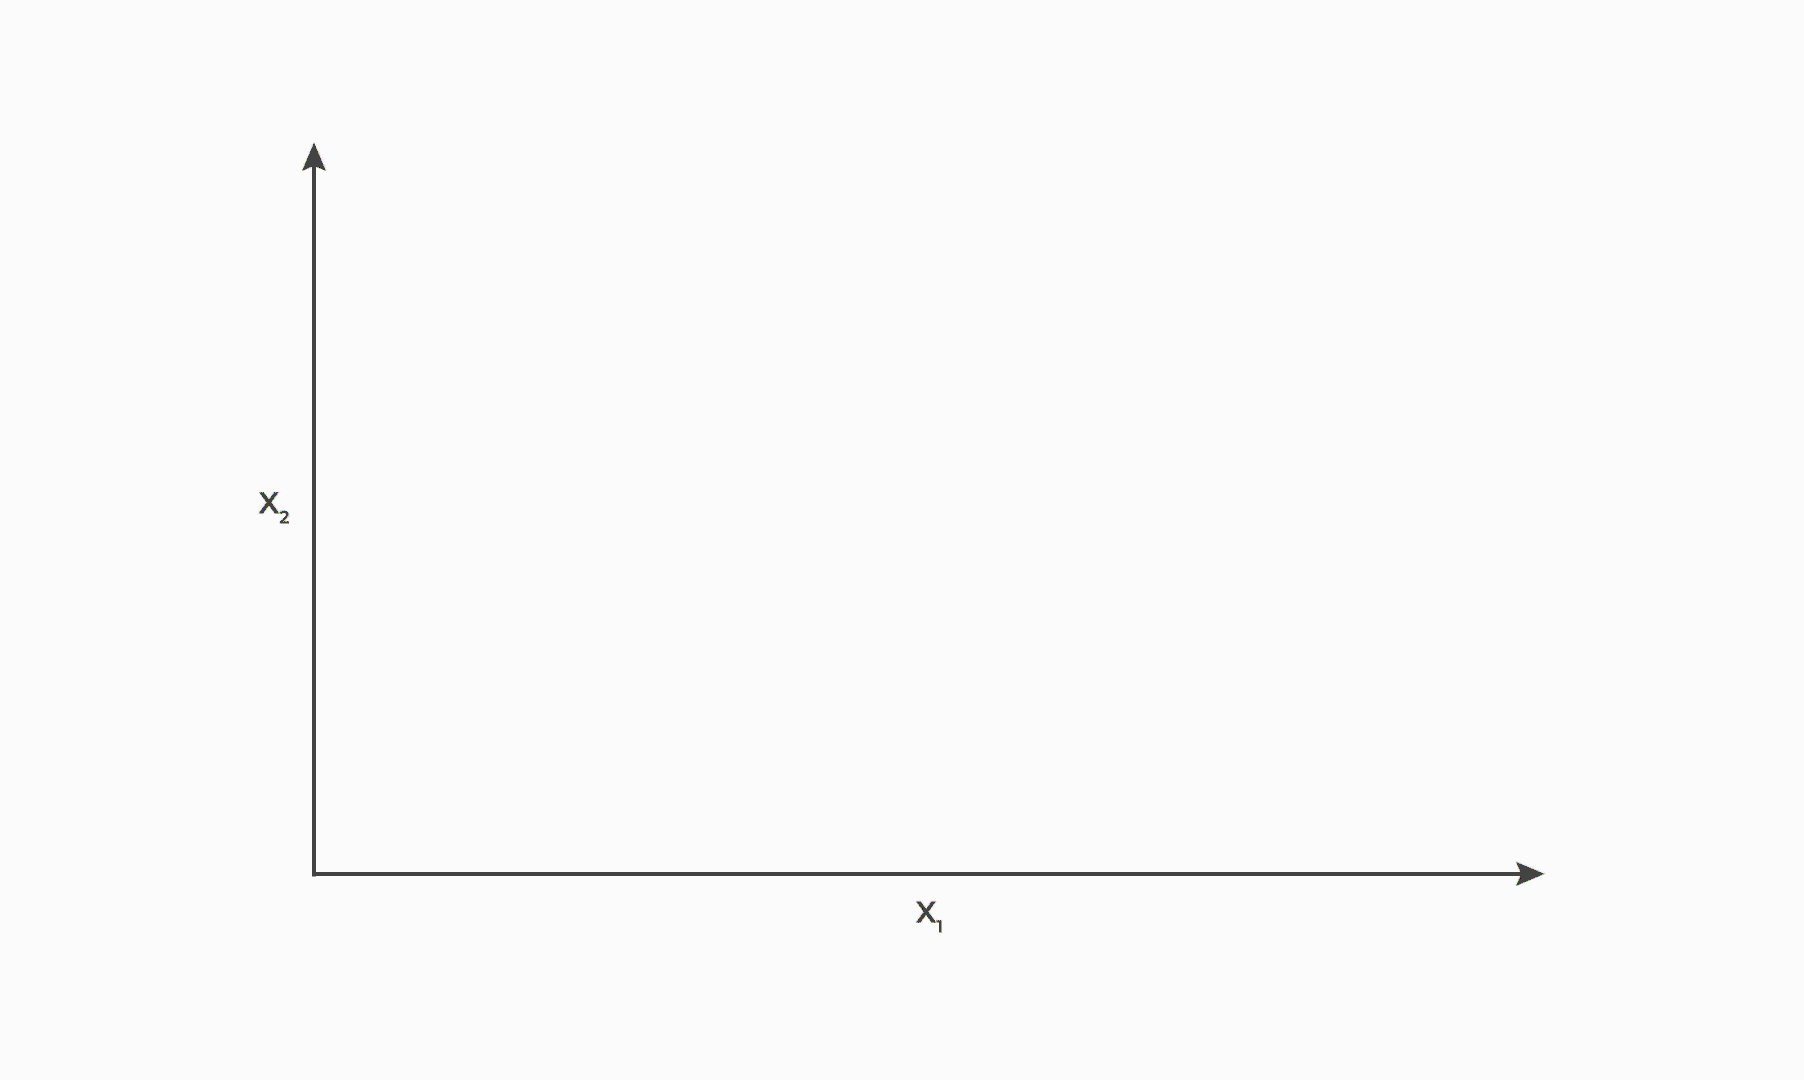   width=700"></p>


</figure>
<figcaption> Figure 1: Model-based learning(will be changed, needs labeling and change new data as x)</figcaption>
</center>

Figure 1 demonstrates model-based learning for binary classification. Here, the model learns the decision boundary denoted by the red line using a training sample. Prediction of new unseen data (X) is based on which side of the boundary it falls on, right side - green, left side - blue.


### Instance-based learning

Another approach for creating the emotion detection system is using the essence of similarity. i.e. **Similar input data have similar target values/labels**. The system first memorizes/stores(rote) all the training corpus in memory in the approach. It then predicts the unseen document's emotion label as the emotion of most closely resembling(similar) stored document. A simple similarity measure between the unseen and stored document would be common word counts. Such a system classifies as **instance-based learning** because it's based on comparing unseen instances with stored training instances.


<center>
<figure>


<p><img src="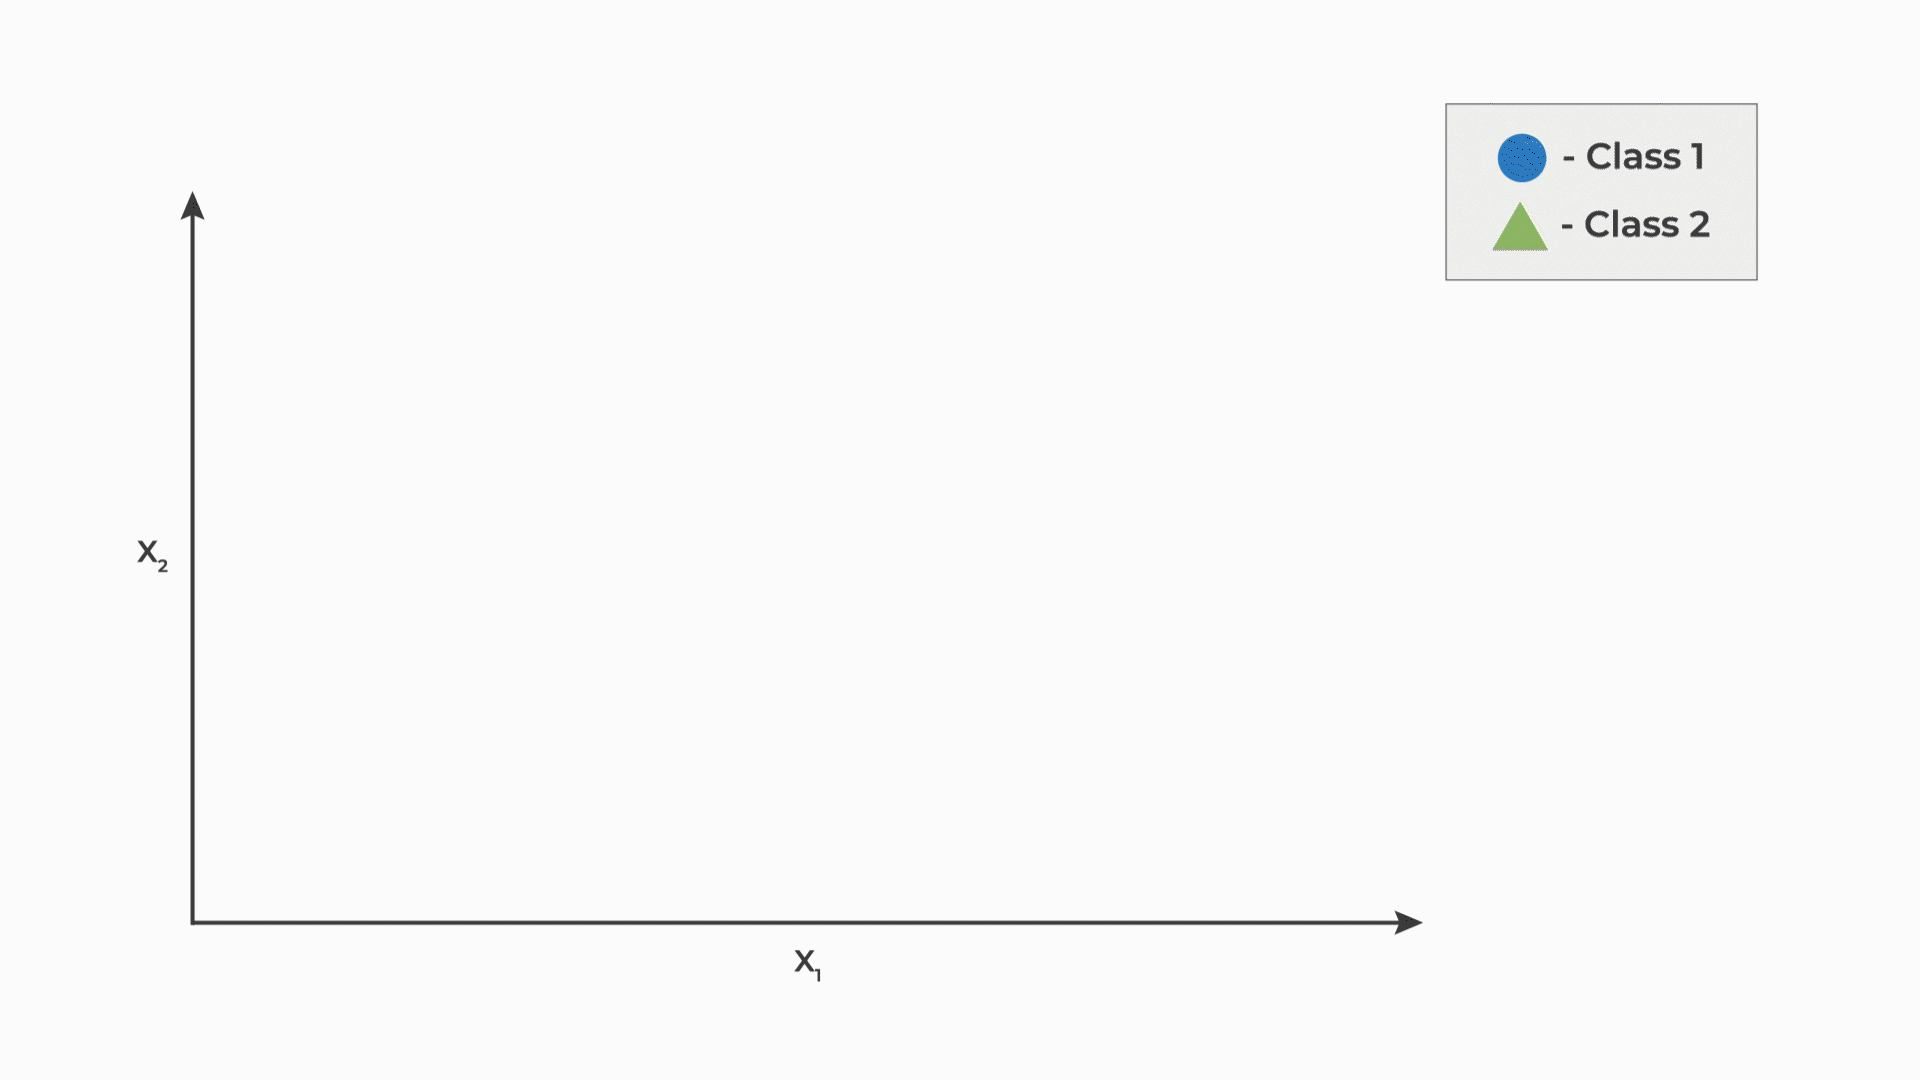   width=700"></p>


</figure>
<figcaption> Figure 2: Instance-based learning</figcaption>
</center>

Figure 2 demonstrates an instance-based learning system for a similar binary classification problem on two-dimensional space. After storing training instances, a new sample(x) is compared with stored instances using distance metrics (similarly measure). The new sample's label is a triangle as the most similar training instance belonged to the triangle class. 

Note: Instance-based learning models are heavily dependent on similarity measures whose output is affected by feature magnitudes. **Feature scaling is mandatory preprocessing in these models** for proper functioning.


#### Working of instance-based learning

Instance-based learning, aka lazy learners/memory-based learning, is a non-parametric *supervised* learning method that, instead of learning the underlying structure(explicit generalization), works by:

1. First, storing all the training examples in the memory - training phase.
2. Then, for new unseen sample, predicts target value using its relationship(similarly measure) with the stored instances - prediction phase.


#### Characteristic of instance-based learning

Unlike model-based learning models, instance-based learning models have different characteristics that are:

- The hypothesis function isn't constant; the estimation of hypothesis function is proportional to the number of training samples. There are *no assumptions regarding the number of parameters of the model* that construct the hypothesis function. Consequently the name, *non-parametric models*.


- These systems *processes training data only when unseen data is to be predicted*. So, they are referred to as *lazy learners*.

Few instance-based learning algorithms are **K-nearest neighbors**(K-NN), [locally weighted regression]( https://en.wikipedia.org/wiki/Local_regression), [radial basis function]( https://en.wikipedia.org/wiki/Radial_basis_function), and [kernel machines]( https://en.wikipedia.org/wiki/Kernel_method). Among these, K-NN is the most popular algorithm that you are learning in this unit. Discussing other algorithms is beyond the scope of this course. Before learning KNN, let's discuss the advantages and disadvantages of the instance-based learning model.


### Advantage/Disadvantage of instance-based learning


#### Advantages

Using similarity measure for prediction of new samples instead of approximating function, the advantages of instance-based learning are as follows:

* Simple to understand, prediction related to finding similar data points along with instant training. 

* Works exceptionally in an "online" learning scenario, where the system trains incrementally using batches of continuous data instances. In this case, adding new data observed requires only an update to the database.

* Acquiring new data of some class does not degrade the model performance of older instances. i.e., Due to local approximation of hypothesis, instance-based learning models have tolerance for data interference


#### Disadvantages

The instance-based learning model can't discard the training data. For finding a similarity measure of a new sample, these models query all the attributes/features of _all training samples_. As a result, the disadvantages are:

* Requirement of a large amount of memory to store the data.

* Sluggish during the query time for a large number of training data. Linear increment in computational complexity.

* Due to curse of dimensionality, performance degradation for high dimensional data samples. i.e., Worse performance on a dataset with a huge number of features.

That's all for the discussion on instance-based learning, now let's discuss its most popular algorithm, KNN.


## Introduction to K-NN

To better understand KNN, let's start with an example.


### Binary classification example

Having the synthetic restaurant dataset present below with categorical features such as food quality, ambience, hygiene, and service, you are building an instance-based machine learning system for a binary classification problem, predicting whether the restaurant will rise to popularity or fail miserably(target variable).

<center>
Table 1: Synthetic restaurant dataset
</center>

| Id | Food quality | Ambience | Hygiene | Service | Will fail? |
|-|-|-|-|-|-|
| 1. | High | Low | Medium | Low | Yes |
| 2. | Medium | Medium | Medium | High | No |
| 3. | Low | Low | Low | Low | Yes |
| 4. | Medium | High | High | Medium | No |
| 5. | Low | High | Low | High | Yes |
| 6. | High | Medium | Low | Low | Yes |

Let's try to think of methods to build an ML system for the problem mentioned above. 


### Rote learning

We can start by finding exact samples in the stored set. That's called **rote learning**, where the new sample requires an exact match of features with one of the stored training data. Say a new sample is as follows:

<center>Table 2: Synthetic restaurant data's test sample 1</center>

| Id | Food quality | Ambience | Hygiene | Service | Will fail? |
|-|-|-|-|-|-|
|-| Low | High | Low | High | - |

This new sample exactly matches with the Id-5 of the training set. So the prediction of the new sample is the target value of Id-5, i.e., "Yes." However, there is a flaw. If there isn't a matching sample in the training set, then this method fails. How can we improve this method?


### Nearest neighbor algorithm

**Nearest neighbor search** that you studied in the previous unit improves the rote learning model. The main assumption being **similar samples have similar targets**. After storing the training data, the nearest neighbor predictor works in the following way:

1. First, find the nearest neighbor of the new sample(here, using hamming distance).

2. Then, predicts the new sample's target value as that of the nearest neighbor training sample.

This method is referred to as the **1-nearest neighbor**(1-NN) classifier. 

<center>Table 3: Synthetic restaurant data's test sample 2</center>

| Id | Food quality | Ambience | Hygiene | Service | Will fail? |
|-|-|-|-|-|-|
|-| Medium| Medium | Low | High | - |

Applying 1-NN, the closest training sample for the above new sample is Id-2, matching three features. So, the target prediction of the new sample is "No."


### K-NN algorithm

We can still improve 1-NN algorithm, let's use an analogy to understand how. When we are buying a house, we often compare the prices among multiple neighboring house(neighborhood, we will discuss more about neighbor/neighborhood in clustering unit) for predicting price, don't we? So, instead of one nearest neighbor, how about taking *arbitary(K) number of nearest neighbors* of the new sample into account for prediction? This is the **K-Nearest Neighbor(K-NN)** algorithm that generalizes nearest neighbor algorithm over multiple($K$) neighbors.

K-NN is a simple, instance-based learning algorithm, used for *classification and regression problems*. The main assumption of K-NN being similar input features have similar target values.


#### Working of K-NN

The K-NN algorithm consists of two steps, training phase, and prediction phase, but before that user must set the hyperparameters of the K-NN model as:

- Setting hyperparameters

  - Choose the number of neighbors($K$) to examine and a distance function($d$) for similarity measure.

Now, the training and prediction phase conducts as follows:

1. Training phase

  - Store the training dataset in memory. Note: Using spatial-access methods such as kd-tree, ball-tree, and storing data structure allows faster neighbor search/query.


2. Prediction phase

  1. Given a test sample, compute its "$K$"-nearest neighbors.
  2. Predict the target value of the test sample:
    - For classification
       - **Assign the target label by majority voting**. The highest count/frequency of class labels among the K-nearest neighbors is the test sample's target label.
       
     - For regression
        - **Assign the target value by aggregate scheme**. The mean of the target value of K-nearest neighbors is the target value for the test sample.
      
        


Continuing the above restaurant binary classification task, let's use the K-NN algorithm with the value of K set to 3:

1. First, 3-NN computes the three nearest neighbors for the new sample 2(present in table 3): Id-2, Id-5, and Id-6(with Id-5,6 having two matching features).

2. Then, assigns the target variable of the new sample as the highest count target label among the nearest neighbors, 

$$\text{mode("No", "Yes", "Yes")= "Yes"}$$

**Note**: For predicting the target of a new sample without using advanced data structures, the new sample is compared with $n$ stored training samples. So, the worst computational complexity for predicting a new sample's target is $O(n)$.


That's all for this notebook. In the next chapters, we will dive in-depth into K-NN classifier and regressor along with visulization, discussion on effect of K and pros/cons.


## Key takeaways

Key-points to note from this notebook are:

1. Model-based learning system learns parameters/hypothesis function from training samples. The hypothesis function predicts the target value of unseen samples.


2. Instance-based learning, lazy-learning model is a non-parametric system that learns by memorizing training samples. Prediction of an unseen sample's target is inferred from a similar stored training sample.


3. Instance-based learning system works for a large number of samples and is exceptional in online learning. However, these systems require large memory space, are sluggish for large feature dimensions, and suffer from the curse of dimensionality.


4. Conducting feature scaling is important being training/prediction in instance-based learning models due to their dependency on similarity measures(distance metrics).


5. Most popular instance-based learning algorithm is K-NN, the nearest neighbor search, simple supervised classification/regression algorithm.


6. First, K-NN stores the training sample, then predicting the new sample's target queries the $K$-nearest neighbors. The new sample's target value is either average of its neighbors(for regression) or its neighbors' highest count label (for classification).


## References

Books

1. Kirk, M. (2017), "Thoughtful machine learning with Python, A test-driven approach", Chapter-3 K-Nearest Neighbors, pg 21-24. 
    - Develops intuitive approach on how K-nearest neighbor algorithm came to be using example of house price prediction.
    
    
2. Geron, A. (2019), "Hands-on Machine Learning with Scikit-Learn, Keras and TensorFlow", Chapter-1 The Machine Learning Landscape, pg 18. 
    - Develops intuition on instance-based learning.


## Additional material

1. [K-NN Demo by Stanford.]( http://vision.stanford.edu/teaching/cs231n-demos/knn/)

    - Interactive playground to see K-NN in action. You can change metrics, $K$, Number of classes, and samples. Try it!
